# Maker Strategy Data Analysis

Step-by-step notebook for validating maker strategies on Kalshi using collected
order book depth, candlestick data, and cross-category snapshots.

**Goal:** Determine whether an informed limit-order (maker) strategy has a real edge
on Kalshi, and if cross-category Bayesian updating adds value.

**Workflow:**
1. **Market Universe Discovery** — Explore series, spread/volume by category
2. **Order Book Depth** — Analyze bid-ask levels and thickness
3. **Realized Volatility** — Compute logit-space vol from candlestick OHLC
4. **Maker Edge Estimation** — `half_spread − maker_fee` by category
5. **Cross-Category Correlation** — Logit-return correlation matrix + lead-lag
6. **Informed Limit-Order P&L Simulation** — Kelly-sized maker backtest
7. **Decision Gate** — Aggregate go/no-go for Phase 2

**Prerequisites:**
- Run the arbiter scanner with expanded series to populate `MarketSnapshot` rows
- Run `DataCollector` to populate `OrderBookSnapshot` rows
- Run `scripts/backfill_candles.py` to populate `CandlestickBar` rows

**Key concepts:**
- All volatility computed in **logit space**: `logit(p) = log(p/(1−p))` per Dalen (2025)
- Maker fees use Kalshi parabolic model: `ceil(0.0175 × P × (1−P) × 100) / 100`
- Taker fees are 4× higher: `ceil(0.07 × P × (1−P) × 100) / 100`

In [1]:
# --- Setup: autoreload, imports, and plotting defaults ---
# autoreload lets us edit arbiter source and pick up changes without restarting the kernel

%load_ext autoreload
%autoreload 2

from datetime import UTC, datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

from arbiter.scoring.fees import kalshi_fee
from arbiter.scoring.kelly import kelly_criterion

# Data directory — populated by: make maker-data
DATA_DIR = Path("..") / "data"

# Target series for maker strategy evaluation
TARGET_SERIES = [
    "KXCPI", "KXCPIYOY", "KXCPICOREYOY",
    "KXPAYROLLS", "KXJOBLESSCLAIMS", "KXGDP",
    "KXFED", "KXBTCD", "KXETHD", "KXINXU", "KXNASDAQ100U",
]

# Consistent color palette for all plots
COLORS = {
    "primary": "#4C72B0",
    "profit": "#55A868",
    "loss": "#C44E52",
    "muted": "#8C8C8C",
}

---
## Step 1 — Market Universe Discovery

**Purpose:** Explore all available Kalshi series to understand which categories
have the widest spreads (= highest maker opportunity) and most volume.

**What this cell does:**
1. Loads all `MarketSnapshot` rows from the database via `export_snapshots()`
2. Extracts the series prefix from each contract_id (e.g., `KXCPI` from `KXCPI-26MAR-T0.4`)
3. Groups by series and computes: snapshot count, unique contracts, avg spread, avg volume, avg price
4. Sorts by average spread (descending) — wider spreads = more maker opportunity

**What to look for:**
- Series with `avg_spread > 0.04` are interesting for maker strategies
- Low `unique_contracts` might indicate thin markets with execution risk
- Very low volume series may have stale quotes (spreads look wide but aren't fillable)

In [2]:
# Load MarketSnapshot data from parquet.
# Populated by: make maker-snapshots (or make maker-data)

snapshots_path = DATA_DIR / "snapshots.parquet"
if snapshots_path.exists():
    df = pd.read_parquet(snapshots_path)
    df["snapshot_at"] = pd.to_datetime(df["snapshot_at"])
    print(f"Loaded {len(df)} snapshots from {snapshots_path}")

    # Use series_ticker from data; fall back to extracting prefix from contract_id
    df["series"] = df["series_ticker"].where(
        df["series_ticker"].notna() & (df["series_ticker"] != ""),
        df["contract_id"].str.split("-").str[0],
    )

    # Summary stats per series — sorted by avg spread to highlight maker targets
    summary = (
        df.groupby("series")
        .agg(
            snapshots=("contract_id", "count"),
            unique_contracts=("contract_id", "nunique"),
            avg_spread=("bid_ask_spread", "mean"),
            avg_volume=("log_volume_24h", lambda x: np.exp(x.mean())),
            avg_price=("yes_price", "mean"),
        )
        .round(4)
        .sort_values("avg_spread", ascending=False)
    )
    print("\nMarket summary by series (sorted by avg spread):")
    display(summary)

    # --- Target series subset ---
    target_in_summary = summary.loc[summary.index.isin(TARGET_SERIES)]
    missing_targets = [s for s in TARGET_SERIES if s not in summary.index]
    print(f"\n--- Target Series ({len(target_in_summary)}/{len(TARGET_SERIES)} found) ---")
    if not target_in_summary.empty:
        display(target_in_summary.sort_values("avg_spread", ascending=False))
    if missing_targets:
        print(f"Missing from snapshot data: {missing_targets}")

    # --- All series with avg_spread > 0.04 (potential maker opportunities) ---
    wide_spread = summary[summary["avg_spread"] > 0.04]
    print(f"\n--- All series with avg_spread > 0.04 ({len(wide_spread)} found) ---")
    if not wide_spread.empty:
        display(wide_spread)
    else:
        print("None found.")
else:
    print(f"No snapshot data at {snapshots_path}")
    print("Run: make maker-snapshots")
    df = pd.DataFrame()

Loaded 1601364 snapshots from ../data/snapshots.parquet

Market summary by series (sorted by avg spread):


,snapshots,unique_contracts,avg_spread,avg_volume,avg_price
series,,,,,
KXLIVMAKECUT,2695,35,0.9800,595.3165,0.5100
KXTOURNAMENTOFCHAMPIONS,1642,20,0.9408,34.5632,0.4723
KXMARMADSEEDWIN,62,1,0.8995,31.7911,0.4799
KXJACWSNOWM,350,3,0.8486,17.1796,0.4907
KXSSHIELDMATCH,83,1,0.8319,12.0000,0.4581
...,...,...,...,...,...
KXAGNOMGAD,32,1,0.0100,441.0000,0.4550
KXETHY,1247,16,0.0034,163.9786,0.0633
KXBTCY,3304,28,0.0033,89.6015,0.0394



--- Target Series (9/11 found) ---


,snapshots,unique_contracts,avg_spread,avg_volume,avg_price
series,,,,,
KXNASDAQ100U,3634,124,0.4000,94.1799,0.5223
KXINXU,7606,136,0.2220,250.3076,0.5797
KXCPI,871,59,0.1286,57.9859,0.4679
KXETHD,21465,424,0.0865,148.2532,0.5280
KXJOBLESSCLAIMS,1788,16,0.0611,98.6496,0.6538
KXCPIYOY,1001,27,0.0507,111.8989,0.3319
KXCPICOREYOY,141,6,0.0421,180.0305,0.5016
KXPAYROLLS,714,35,0.0409,200.3480,0.5159
KXBTCD,41010,971,0.0214,1231.7286,0.4826


Missing from snapshot data: ['KXGDP', 'KXFED']

--- All series with avg_spread > 0.04 (408 found) ---


,snapshots,unique_contracts,avg_spread,avg_volume,avg_price
series,,,,,
KXLIVMAKECUT,2695,35,0.9800,595.3165,0.5100
KXTOURNAMENTOFCHAMPIONS,1642,20,0.9408,34.5632,0.4723
KXMARMADSEEDWIN,62,1,0.8995,31.7911,0.4799
KXJACWSNOWM,350,3,0.8486,17.1796,0.4907
KXSSHIELDMATCH,83,1,0.8319,12.0000,0.4581
...,...,...,...,...,...
KXPAYROLLS,714,35,0.0409,200.3480,0.5159
KXRAINDALM,689,7,0.0409,85.8352,0.4616
KXTECHLAYOFF,110,1,0.0403,214.9928,0.5494


---
## Step 2 — Order Book Depth Analysis

**Purpose:** Examine bid-ask depth across categories to understand market microstructure.

**Key questions:**
- How many price levels does a typical order book have?
- How much size sits at top-of-book vs deeper levels?
- Which categories have the thinnest books (= easiest to provide liquidity)?

**What this cell does:**
1. Queries the `OrderBookSnapshot` table (populated by `DataCollector`)
2. Counts bid/ask levels per snapshot
3. Groups by series to show average depth

**What to look for:**
- Thin books (`avg_bid_levels < 3`) are easiest to compete in as a maker
- Deep books (> 10 levels) indicate institutional presence (e.g., SIG on economics)
- Empty books (0 levels) mean the market is too illiquid to trade

**Requires:** `OrderBookSnapshot` table populated by `DataCollector`.

In [4]:
# Load order book data from parquet.
# Populated by: make maker-orderbooks (or make maker-data)

ob_path = DATA_DIR / "orderbooks.parquet"
if ob_path.exists():
    df_ob = pd.read_parquet(ob_path)
    df_ob["snapshot_at"] = pd.to_datetime(df_ob["snapshot_at"])
    print(f"Loaded {len(df_ob)} order book snapshots from {ob_path}")

    df_ob["num_bid_levels"] = df_ob["bids"].apply(lambda b: len(b) if b is not None and len(b) > 0 else 0)
    df_ob["num_ask_levels"] = df_ob["asks"].apply(lambda a: len(a) if a is not None and len(a) > 0 else 0)

    # Use series_ticker; fall back to splitting contract_id on "-"
    df_ob["series"] = df_ob["series_ticker"].where(
        df_ob["series_ticker"].notna() & (df_ob["series_ticker"] != ""),
        df_ob["contract_id"].str.split("-").str[0],
    )

    # Average depth by series — fewer levels = thinner book = more maker opportunity
    depth_summary = (
        df_ob.groupby("series")
        .agg(
            snapshots=("contract_id", "count"),
            avg_bid_levels=("num_bid_levels", "mean"),
            avg_ask_levels=("num_ask_levels", "mean"),
        )
        .round(2)
        .sort_values("avg_bid_levels")
    )
    print("\nOrder book depth by series (fewer levels = thinner book):")
    display(depth_summary)

    # --- Report which target series are missing from order book data ---
    ob_series = set(depth_summary.index)
    ob_missing = [s for s in TARGET_SERIES if s not in ob_series]
    ob_present = [s for s in TARGET_SERIES if s in ob_series]
    print(f"\n--- Target series in order book data: {len(ob_present)}/{len(TARGET_SERIES)} ---")
    if ob_present:
        display(depth_summary.loc[depth_summary.index.isin(TARGET_SERIES)])
    if ob_missing:
        print(f"Missing from order book data: {ob_missing}")
        print("  -> Run: make maker-orderbooks")
    ob_data = df_ob.to_dict("records")  # for step 7 prerequisite check
else:
    print(f"No order book data at {ob_path}")
    print("Run: make maker-orderbooks")
    ob_data = []

Loaded 156 order book snapshots from ../data/orderbooks.parquet

Order book depth by series (fewer levels = thinner book):


,snapshots,avg_bid_levels,avg_ask_levels
series,,,
KXNASDAQ100U,8,1.50,2.00
KXINXU,19,4.11,3.42
KXCPIYOY,19,4.84,7.32
KXJOBLESSCLAIMS,8,4.88,6.00
KXCPICOREYOY,5,5.20,10.60
KXCPI,20,5.65,5.80
KXETHD,20,8.35,7.55
KXPAYROLLS,10,8.50,11.70
KXFED,20,9.35,11.30



--- Target series in order book data: 11/11 ---


,snapshots,avg_bid_levels,avg_ask_levels
series,,,
KXNASDAQ100U,8,1.50,2.00
KXINXU,19,4.11,3.42
KXCPIYOY,19,4.84,7.32
KXJOBLESSCLAIMS,8,4.88,6.00
KXCPICOREYOY,5,5.20,10.60
KXCPI,20,5.65,5.80
KXETHD,20,8.35,7.55
KXPAYROLLS,10,8.50,11.70
KXFED,20,9.35,11.30


---
## Step 3 — Realized Volatility from Candlesticks

**Purpose:** Compute realized volatility using candlestick OHLC data to understand
which contracts move the most (and thus have the most maker risk/opportunity).

**Volatility estimators used:**
- **Close-to-close**: `std(Δlogit(close))` — simple, but misses intra-period moves
- **Parkinson (high-low)**: More efficient, uses the full intra-period range
- Both computed in **logit space** per Dalen (2025): `logit(p) = log(p/(1−p))`

**Why logit space?**
Raw prices are bounded [0, 1], so `std(prices)` is misleading — a contract at 0.95
can't move much upward, but `logit(0.95) = 2.94` vs `logit(0.50) = 0.0`, giving
proper unbounded returns for standard volatility estimators.

**What to look for:**
- High-vol series are attractive for informed makers (more mispricing opportunities)
- Very low vol may mean the market is efficiently priced (hard to capture edge)
- Compare Parkinson vs close-to-close: big gaps suggest important intra-period moves

**Requires:** `CandlestickBar` table populated by `scripts/backfill_candles.py`.

Loaded 65654 candlestick bars from ../data/candles.parquet
Hourly bars: 65654

Computed volatility for 225 contracts

Realized volatility by series (logit-space, annualized):


,contracts,avg_cc_vol,avg_pk_vol,avg_price
series,,,,
KXNASDAQ100U,8,292.5932,34.8229,0.1640
KXINXU,18,280.9453,22.6495,0.1633
KXETHD,23,234.8176,3.0470,0.1261
KXBTCD,47,220.3322,4.6575,0.1798
KXJOBLESSCLAIMS,8,216.2451,1.6656,0.0999
KXGDP,7,215.7897,6.8759,0.1048
KXCPICOREYOY,5,177.7247,10.0290,0.0724
KXCPIYOY,19,167.1385,4.5844,0.0856
KXCPI,58,128.8940,5.0062,0.0412


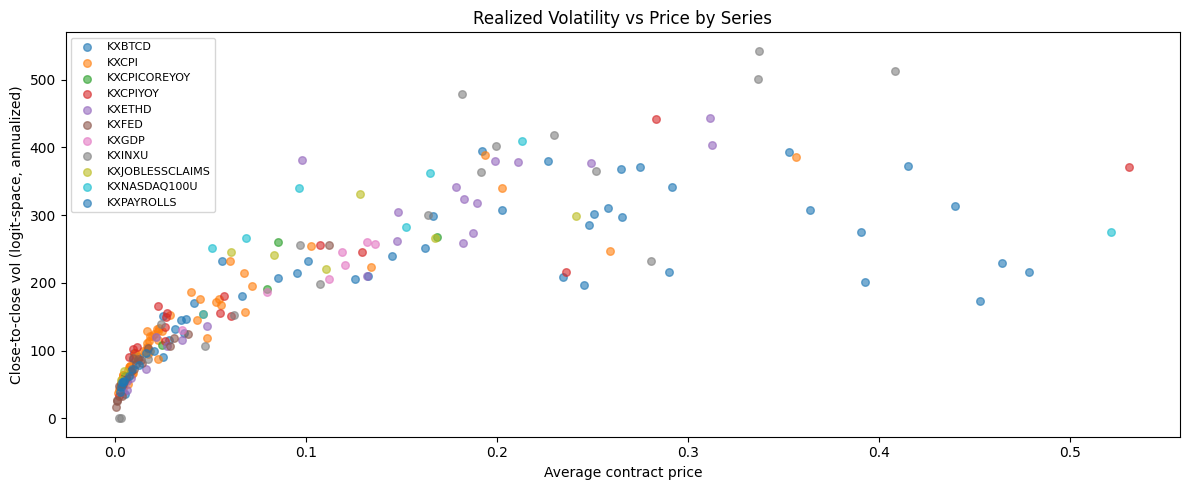


--- Target Series Volatility (11/11 found) ---


,contracts,avg_cc_vol,avg_pk_vol,avg_price
series,,,,
KXNASDAQ100U,8,292.5932,34.8229,0.1640
KXINXU,18,280.9453,22.6495,0.1633
KXETHD,23,234.8176,3.0470,0.1261
KXBTCD,47,220.3322,4.6575,0.1798
KXJOBLESSCLAIMS,8,216.2451,1.6656,0.0999
KXGDP,7,215.7897,6.8759,0.1048
KXCPICOREYOY,5,177.7247,10.0290,0.0724
KXCPIYOY,19,167.1385,4.5844,0.0856
KXCPI,58,128.8940,5.0062,0.0412


In [5]:
# Volatility estimators in logit space.
# safe_logit clips prices to [0.01, 0.99] to avoid log(0) = -inf at boundaries.

from scipy.special import logit as scipy_logit


def safe_logit(p: np.ndarray, clip: float = 0.01) -> np.ndarray:
    """Logit transform with clipping to avoid inf at 0 and 1."""
    return scipy_logit(np.clip(p, clip, 1 - clip))


def close_to_close_vol(prices: np.ndarray, periods_per_day: int = 24) -> float:
    """Annualized close-to-close vol in logit space."""
    logits = safe_logit(prices)
    returns = np.diff(logits)
    if len(returns) < 2:
        return np.nan
    return float(np.std(returns, ddof=1) * np.sqrt(periods_per_day * 365))


def parkinson_vol(highs: np.ndarray, lows: np.ndarray, periods_per_day: int = 24) -> float:
    """Parkinson high-low volatility estimator in logit space."""
    h = safe_logit(highs)
    l = safe_logit(lows)
    n = len(h)
    if n < 1:
        return np.nan
    pk_var = (1 / (4 * n * np.log(2))) * np.sum((h - l) ** 2)
    return float(np.sqrt(pk_var * periods_per_day * 365))


# Load candlestick data from parquet.
# Populated by: make maker-candles (or make maker-data)

candles_path = DATA_DIR / "candles.parquet"
if candles_path.exists():
    df_candles = pd.read_parquet(candles_path)
    df_candles["period_start"] = pd.to_datetime(df_candles["period_start"])
    print(f"Loaded {len(df_candles)} candlestick bars from {candles_path}")

    # Use series_ticker; fall back to splitting contract_id on "-"
    df_candles["series"] = df_candles["series_ticker"].where(
        df_candles["series_ticker"].notna() & (df_candles["series_ticker"] != ""),
        df_candles["contract_id"].str.split("-").str[0],
    )

    # Filter to 1-hour bars (period_interval=60 minutes)
    hourly = df_candles[df_candles["period_interval"] == 60].copy()
    print(f"Hourly bars: {len(hourly)}")

    # Compute per-contract realized vol using both estimators
    vol_records = []
    for cid, group in hourly.groupby("contract_id"):
        group = group.sort_values("period_start")
        if len(group) < 5:  # need at least 5 bars for meaningful vol estimate
            continue
        cc_vol = close_to_close_vol(group["close"].values)
        pk_vol = parkinson_vol(group["high"].values, group["low"].values)
        vol_records.append({
            "contract_id": cid,
            "series": group["series"].iloc[0],
            "n_bars": len(group),
            "close_to_close_vol": cc_vol,
            "parkinson_vol": pk_vol,
            "avg_price": group["close"].mean(),
        })

    df_vol = pd.DataFrame(vol_records)
    print(f"\nComputed volatility for {len(df_vol)} contracts")
    candle_data = df_candles.to_dict("records")  # for step 7 prerequisite check

    if not df_vol.empty:
        # Aggregate vol by series
        vol_by_series = (
            df_vol.groupby("series")
            .agg(
                contracts=("contract_id", "count"),
                avg_cc_vol=("close_to_close_vol", "mean"),
                avg_pk_vol=("parkinson_vol", "mean"),
                avg_price=("avg_price", "mean"),
            )
            .round(4)
            .sort_values("avg_cc_vol", ascending=False)
        )
        print("\nRealized volatility by series (logit-space, annualized):")
        display(vol_by_series)

        # Scatter plot: vol vs price, colored by series
        fig, ax = plt.subplots(figsize=(12, 5))
        for series in df_vol["series"].unique():
            sub = df_vol[df_vol["series"] == series]
            ax.scatter(
                sub["avg_price"], sub["close_to_close_vol"],
                alpha=0.6, s=30, label=series,
            )
        ax.set_xlabel("Average contract price")
        ax.set_ylabel("Close-to-close vol (logit-space, annualized)")
        ax.set_title("Realized Volatility vs Price by Series")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

        # --- Target series volatility subset ---
        target_vol = vol_by_series.loc[vol_by_series.index.isin(TARGET_SERIES)]
        vol_missing = [s for s in TARGET_SERIES if s not in vol_by_series.index]
        print(f"\n--- Target Series Volatility ({len(target_vol)}/{len(TARGET_SERIES)} found) ---")
        if not target_vol.empty:
            display(target_vol.sort_values("avg_cc_vol", ascending=False))
        if vol_missing:
            print(f"Missing from candlestick data: {vol_missing}")

        # --- Data quality: target series with zero vol ---
        if not target_vol.empty:
            zero_vol = target_vol[target_vol["avg_cc_vol"] == 0.0]
            if not zero_vol.empty:
                print(f"\nDATA QUALITY FLAG: {len(zero_vol)} target series have zero vol:")
                display(zero_vol)
else:
    print(f"No candlestick data at {candles_path}")
    print("Run: make maker-candles")
    candle_data = []

---
## Step 4 — Maker Edge Estimation

**Purpose:** Estimate the theoretical maker edge per category before adverse selection.

**Formula:**
```
maker_edge = half_spread − maker_fee
           = (yes_ask − yes_bid) / 2 − ceil(0.0175 × P × (1−P) × 100) / 100
```

This is a **best-case estimate** — real edge is lower due to adverse selection
(the probability that you get filled because someone with better information
is trading against you). Adverse selection modeling is deferred to Phase 2.

**What this cell does:**
1. Computes maker and taker fees at each snapshot's midpoint price
2. Computes `half_spread − fee` for both maker and taker
3. Groups by series to show average edge and % of snapshots with positive edge
4. Plots the Kalshi parabolic fee curves and edge distribution

**What to look for:**
- `avg_maker_edge > 0.01` (1 cent) = interesting category for maker strategy
- `pct_positive_edge > 0.5` = more than half the time the spread exceeds the fee
- Compare maker vs taker edge — the 4x fee difference is the structural advantage

Theoretical maker edge by series (spread/2 - maker_fee):
Note: does NOT include adverse selection cost



,n,avg_spread,avg_maker_fee,avg_taker_fee,avg_maker_edge,pct_positive_edge
series,,,,,,
KXLIVMAKECUT,2695,0.9800,0.01,0.0200,0.4800,1.0000
KXTOURNAMENTOFCHAMPIONS,1642,0.9408,0.01,0.0200,0.4604,1.0000
KXMARMADSEEDWIN,62,0.8995,0.01,0.0194,0.4398,1.0000
KXJACWSNOWM,350,0.8486,0.01,0.0199,0.4143,1.0000
KXSSHIELDMATCH,83,0.8319,0.01,0.0200,0.4060,1.0000
...,...,...,...,...,...,...
KXTARIFFREFUND,37,0.0100,0.01,0.0200,-0.0050,0.0000
KXETHY,1247,0.0034,0.01,0.0100,-0.0083,0.0241
KXCITRINI,82,0.0032,0.01,0.0100,-0.0084,0.0000


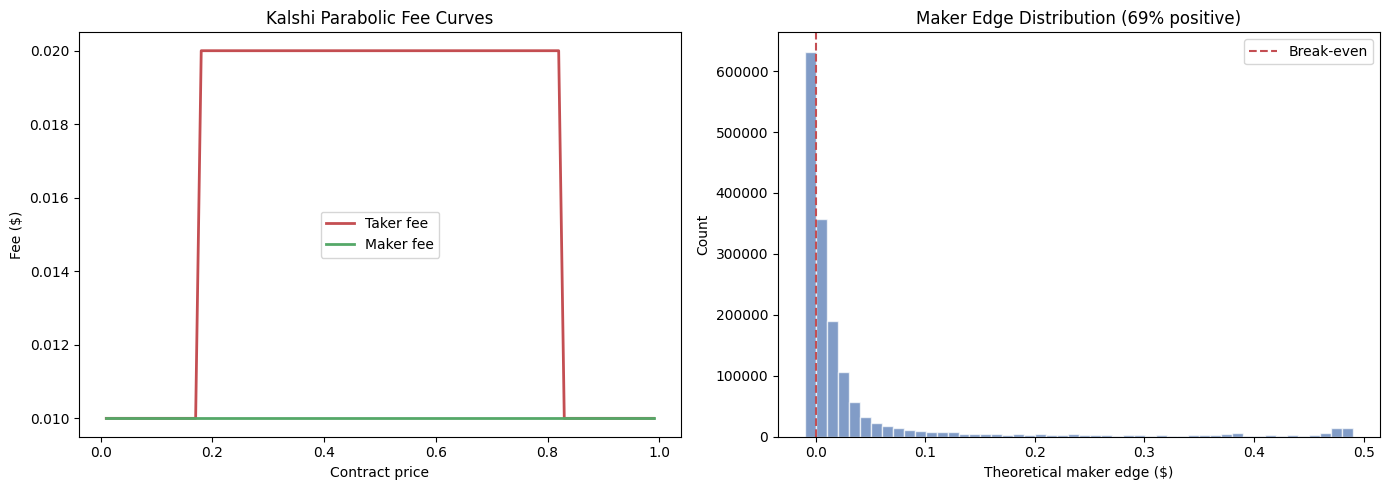


--- Target Series Maker Edge (9/11 found) ---


,n,avg_spread,avg_maker_fee,avg_taker_fee,avg_maker_edge,pct_positive_edge
series,,,,,,
KXNASDAQ100U,3634,0.4000,0.01,0.0157,0.1900,0.8041
KXINXU,7606,0.2220,0.01,0.0156,0.1010,0.8343
KXCPI,871,0.1286,0.01,0.0154,0.0543,0.7899
KXETHD,21465,0.0865,0.01,0.0127,0.0332,0.6666
KXJOBLESSCLAIMS,1788,0.0611,0.01,0.0156,0.0205,0.8680
KXCPIYOY,1001,0.0507,0.01,0.0136,0.0153,0.6344
KXCPICOREYOY,141,0.0421,0.01,0.0148,0.0111,0.6454
KXPAYROLLS,714,0.0409,0.01,0.0180,0.0104,0.6036
KXBTCD,41010,0.0214,0.01,0.0122,0.0007,0.4170


Missing from snapshot data: ['KXGDP', 'KXFED']

--- ALL series with avg_maker_edge > 0.01: 407 series ---


,n,avg_spread,avg_maker_fee,avg_taker_fee,avg_maker_edge,pct_positive_edge
series,,,,,,
KXLIVMAKECUT,2695,0.9800,0.01,0.0200,0.4800,1.0000
KXTOURNAMENTOFCHAMPIONS,1642,0.9408,0.01,0.0200,0.4604,1.0000
KXMARMADSEEDWIN,62,0.8995,0.01,0.0194,0.4398,1.0000
KXJACWSNOWM,350,0.8486,0.01,0.0199,0.4143,1.0000
KXSSHIELDMATCH,83,0.8319,0.01,0.0200,0.4060,1.0000
...,...,...,...,...,...,...
KXRAINDALM,689,0.0409,0.01,0.0160,0.0105,0.7533
KXJOINTRUMPADMIN,46,0.0411,0.01,0.0200,0.0105,1.0000
KXPAYROLLS,714,0.0409,0.01,0.0180,0.0104,0.6036


  Targets passing: ['KXNASDAQ100U', 'KXINXU', 'KXCPI', 'KXETHD', 'KXJOBLESSCLAIMS', 'KXCPIYOY', 'KXCPICOREYOY', 'KXPAYROLLS']
  Non-targets passing: 399 series


In [6]:
# Compute maker/taker fees and theoretical edge for each snapshot.
# Vectorized fee computation using numpy (avoids 1.5M row-by-row .apply() calls).

def _kalshi_fee_vectorized(prices: np.ndarray, is_taker: bool = True) -> np.ndarray:
    """Vectorized Kalshi parabolic fee: ceil(coeff * p * (1-p) * 100) / 100."""
    coeff = 0.07 if is_taker else 0.0175
    raw = coeff * prices * (1.0 - prices)
    return np.ceil(raw * 100) / 100

if df.empty:
    print("No snapshot data — run Step 1 first")
else:
    # Midpoint price for fee calculation
    df["midpoint"] = (df["yes_price"] + (1 - df["no_price"])) / 2
    df["half_spread"] = df["bid_ask_spread"] / 2

    # Vectorized fee at midpoint for both maker and taker
    midpoints = df["midpoint"].values
    df["maker_fee"] = _kalshi_fee_vectorized(midpoints, is_taker=False)
    df["taker_fee"] = _kalshi_fee_vectorized(midpoints, is_taker=True)

    # Theoretical edge = what a maker earns minus what they pay in fees
    df["maker_edge_theoretical"] = df["half_spread"] - df["maker_fee"]
    df["taker_edge_theoretical"] = df["half_spread"] - df["taker_fee"]

    # Summary by series — which categories have the best maker edge?
    edge_summary = (
        df.groupby("series")
        .agg(
            n=("contract_id", "count"),
            avg_spread=("bid_ask_spread", "mean"),
            avg_maker_fee=("maker_fee", "mean"),
            avg_taker_fee=("taker_fee", "mean"),
            avg_maker_edge=("maker_edge_theoretical", "mean"),
            pct_positive_edge=("maker_edge_theoretical", lambda x: (x > 0).mean()),
        )
        .round(4)
        .sort_values("avg_maker_edge", ascending=False)
    )
    print("Theoretical maker edge by series (spread/2 - maker_fee):")
    print("Note: does NOT include adverse selection cost\n")
    display(edge_summary)

    # Two-panel plot: fee curves + edge distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left panel: Kalshi parabolic fee curves across all prices
    ax = axes[0]
    prices = np.linspace(0.01, 0.99, 99)
    maker_fees = _kalshi_fee_vectorized(prices, False)
    taker_fees = _kalshi_fee_vectorized(prices, True)
    ax.plot(prices, taker_fees, color=COLORS["loss"], linewidth=2, label="Taker fee")
    ax.plot(prices, maker_fees, color=COLORS["profit"], linewidth=2, label="Maker fee")
    ax.set_xlabel("Contract price")
    ax.set_ylabel("Fee ($)")
    ax.set_title("Kalshi Parabolic Fee Curves")
    ax.legend()

    # Right panel: distribution of maker edge across all snapshots
    ax2 = axes[1]
    ax2.hist(
        df["maker_edge_theoretical"].dropna(), bins=50,
        color=COLORS["primary"], alpha=0.7, edgecolor="white",
    )
    ax2.axvline(x=0, color=COLORS["loss"], linestyle="--", linewidth=1.5, label="Break-even")
    pct_pos = (df["maker_edge_theoretical"] > 0).mean()
    ax2.set_xlabel("Theoretical maker edge ($)")
    ax2.set_ylabel("Count")
    ax2.set_title(f"Maker Edge Distribution ({pct_pos:.0%} positive)")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # --- Target series edge subset ---
    target_edge = edge_summary.loc[edge_summary.index.isin(TARGET_SERIES)]
    edge_missing = [s for s in TARGET_SERIES if s not in edge_summary.index]
    print(f"\n--- Target Series Maker Edge ({len(target_edge)}/{len(TARGET_SERIES)} found) ---")
    if not target_edge.empty:
        display(target_edge.sort_values("avg_maker_edge", ascending=False))
    if edge_missing:
        print(f"Missing from snapshot data: {edge_missing}")

    # --- ALL series passing avg_maker_edge > 0.01 criterion ---
    passing = edge_summary[edge_summary["avg_maker_edge"] > 0.01]
    print(f"\n--- ALL series with avg_maker_edge > 0.01: {len(passing)} series ---")
    if not passing.empty:
        display(passing)
        # Flag which of these are targets vs non-targets
        passing_targets = passing.loc[passing.index.isin(TARGET_SERIES)]
        passing_non_targets = passing.loc[~passing.index.isin(TARGET_SERIES)]
        print(f"  Targets passing: {list(passing_targets.index) if not passing_targets.empty else 'NONE'}")
        print(f"  Non-targets passing: {len(passing_non_targets)} series")
    else:
        print("  NONE — no series has avg_maker_edge > 0.01")

---
## Step 5 — Cross-Category Correlation Analysis

**Purpose:** Test whether price changes in one series predict *future* price changes
in another. This is the foundation for **Approach B: Cross-Category Bayesian Updating**.

**Hypothesis:** When a macro event resolves (e.g., CPI release), correlated contract
series should reprice. If one series reprices before another (temporal lead-lag),
we can use the first mover to update our fair value estimate for the lagging series.

**What this cell does:**
1. Computes logit-space returns per contract between consecutive snapshots
2. Aggregates to series-level hourly returns
3. Computes the Pearson correlation matrix across series (contemporaneous — for reference)
4. Tests for **lead-lag**: does series A at hour `t` predict series B at hour `t+1`?
   Uses `shift()` on the time-indexed pivot so gaps produce NaN (not false adjacency).

**Priority pairs from deep research:**
- CPI vs CPI YoY (same data release, different framing)
- CPI vs Core CPI YoY (related but distinct measures)
- Payrolls vs Jobless Claims (labor market indicators)

**What to look for:**
- Lead-lag `|r| > 0.2` with consistent direction = actionable signal for informed MM
- Contemporaneous `|r| > 0.3` = useful context but NOT the decision criterion
- All lead-lag correlations `< 0.1` = cross-category updating won't work (red flag)

**Important:** Cointegration is ill-suited to binary contracts (finite life,
convergence to 0/1 violates stationarity). We use conditional probability
updating instead.

**Note on C2 criterion:** The decision gate (Step 7) uses lead-lag correlation
(t → t+1), not contemporaneous correlation. For informed market-making, what matters
is whether one series' current move predicts another's *future* move.

Contemporaneous correlation matrix — TARGET SERIES (9 series):
(for reference only — decision gate uses lead-lag below)



series,KXCPI,KXCPIYOY,KXCPICOREYOY,KXPAYROLLS,KXJOBLESSCLAIMS,KXBTCD,KXETHD,KXINXU,KXNASDAQ100U
series,,,,,,,,,
KXCPI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KXCPIYOY,NaN,1.000,NaN,NaN,-0.158,0.729,0.686,0.665,0.808
KXCPICOREYOY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KXPAYROLLS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KXJOBLESSCLAIMS,NaN,-0.158,NaN,NaN,1.000,-0.103,-0.215,-0.254,0.151
KXBTCD,NaN,0.729,NaN,NaN,-0.103,1.000,0.922,0.904,0.824
KXETHD,NaN,0.686,NaN,NaN,-0.215,0.922,1.000,0.873,0.780
KXINXU,NaN,0.665,NaN,NaN,-0.254,0.904,0.873,1.000,0.920
KXNASDAQ100U,NaN,0.808,NaN,NaN,0.151,0.824,0.780,0.920,1.000


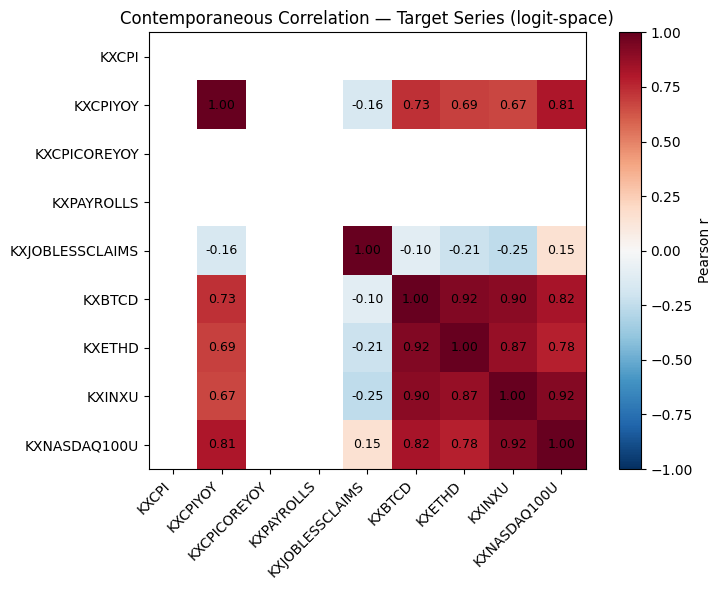


LEAD-LAG ANALYSIS — series A at t vs series B at t+1h (fixed 1-hour lag)
(this is the metric used in the decision gate C2)

Target-target pairs (sorted by |r|):
  Pair                                      r     n  Status
  ----------------------------------- -------  ----  --------------------
  KXNASDAQ100U -> KXCPIYOY            -0.451    19  ⚠ UNRELIABLE (n=19 < 30)
  KXNASDAQ100U -> KXINXU              +0.443    35  *** (credible)
  KXJOBLESSCLAIMS -> KXBTCD           -0.196    24  ⚠ UNRELIABLE (n=24 < 30)
  KXJOBLESSCLAIMS -> KXETHD           -0.191    24  ⚠ UNRELIABLE (n=24 < 30)
  KXCPIYOY -> KXETHD                  +0.159    22  ⚠ UNRELIABLE (n=22 < 30)
  KXBTCD -> KXETHD                    +0.153    45  
  KXBTCD -> KXNASDAQ100U              +0.118    37  
  KXBTCD -> KXCPIYOY                  -0.117    22  ⚠ UNRELIABLE (n=22 < 30)
  KXINXU -> KXETHD                    +0.102    40  
  KXINXU -> KXJOBLESSCLAIMS           -0.101    22  ⚠ UNRELIABLE (n=22 < 30)
  KXINXU -> KXCP

In [7]:
# Compute cross-series correlations using logit-space returns.
# Logit returns are unbounded and well-behaved for correlation analysis.

MIN_PAIRS_RELIABLE = 30  # correlations with fewer pairs are flagged as unreliable

if df.empty:
    print("No snapshot data — run Step 1 first")
else:
    # Sort by contract and time, then compute logit returns
    df_sorted = df.sort_values(["contract_id", "snapshot_at"]).copy()
    df_sorted["logit_price"] = safe_logit(df_sorted["yes_price"].values)
    df_sorted["logit_return"] = df_sorted.groupby("contract_id")["logit_price"].diff()

    # Aggregate to series-level returns per hour for time alignment
    # (different contracts within a series may snapshot at different times)
    df_sorted["hour"] = df_sorted["snapshot_at"].dt.floor("h")

    series_returns = (
        df_sorted.dropna(subset=["logit_return"])
        .groupby(["series", "hour"])["logit_return"]
        .mean()
        .reset_index()
    )

    # Pivot: one column per series, rows are hourly timestamps
    pivot = series_returns.pivot(index="hour", columns="series", values="logit_return")

    # Reindex to a complete hourly grid so gaps become NaN rows.
    # This ensures shift(1) always means exactly 1 hour, not "next available row".
    full_hours = pd.date_range(pivot.index.min(), pivot.index.max(), freq="h")
    pivot = pivot.reindex(full_hours)

    # Filter pivot to target series only for display
    target_cols = [c for c in TARGET_SERIES if c in pivot.columns]
    target_absent = [s for s in TARGET_SERIES if s not in pivot.columns]

    if len(target_cols) >= 2:
        pivot_target = pivot[target_cols]

        # Contemporaneous correlation matrix — TARGET SERIES ONLY (reference, not decision criterion)
        corr_target = pivot_target.corr(min_periods=10)
        print(f"Contemporaneous correlation matrix — TARGET SERIES ({len(target_cols)} series):")
        print("(for reference only — decision gate uses lead-lag below)\n")
        display(corr_target.round(3))

        # Heatmap visualization — target series only
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(corr_target.values, cmap="RdBu_r", vmin=-1, vmax=1)
        ax.set_xticks(range(len(corr_target.columns)))
        ax.set_yticks(range(len(corr_target.columns)))
        ax.set_xticklabels(corr_target.columns, rotation=45, ha="right")
        ax.set_yticklabels(corr_target.columns)
        for i in range(len(corr_target)):
            for j in range(len(corr_target)):
                val = corr_target.iloc[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)
        plt.colorbar(im, ax=ax, label="Pearson r")
        ax.set_title("Contemporaneous Correlation — Target Series (logit-space)")
        plt.tight_layout()
        plt.show()

        # =================================================================
        # Lead-lag analysis: does series A at hour t predict series B at t+1h?
        # Only iterate over target series to avoid O(n²) on all series.
        # Pivot is reindexed to a complete hourly grid, so shift(1) is always
        # exactly 1 hour. Gaps in data are NaN and excluded from correlation.
        # =================================================================
        print("\n" + "=" * 60)
        print("LEAD-LAG ANALYSIS — series A at t vs series B at t+1h (fixed 1-hour lag)")
        print("(this is the metric used in the decision gate C2)")
        print("=" * 60 + "\n")

        lead_lag_results = {}   # {pair_str: r}
        lead_lag_n_pairs = {}   # {pair_str: n}  — sample size for each correlation
        for col_a in target_cols:
            for col_b in target_cols:
                if col_a >= col_b:
                    continue
                # A leads B: corr(A_t, B_{t+1h})
                b_next_hour = pivot[col_b].shift(-1)
                valid = pivot[col_a].notna() & b_next_hour.notna()
                n = int(valid.sum())
                if n >= 10:
                    r = pivot[col_a][valid].corr(b_next_hour[valid])
                    key = f"{col_a} -> {col_b}"
                    lead_lag_results[key] = round(r, 3)
                    lead_lag_n_pairs[key] = n

                # B leads A: corr(B_t, A_{t+1h})
                a_next_hour = pivot[col_a].shift(-1)
                valid = pivot[col_b].notna() & a_next_hour.notna()
                n = int(valid.sum())
                if n >= 10:
                    r = pivot[col_b][valid].corr(a_next_hour[valid])
                    key = f"{col_b} -> {col_a}"
                    lead_lag_results[key] = round(r, 3)
                    lead_lag_n_pairs[key] = n

        # All results are target-target pairs (loop is already filtered)
        lead_lag_target = lead_lag_results
        lead_lag_target_n = lead_lag_n_pairs

        print("Target-target pairs (sorted by |r|):")
        print(f"  {'Pair':<35} {'r':>7}  {'n':>4}  {'Status'}")
        print(f"  {'-'*35} {'-'*7}  {'-'*4}  {'-'*20}")
        if lead_lag_target:
            for pair, r in sorted(lead_lag_target.items(), key=lambda x: abs(x[1]), reverse=True):
                n = lead_lag_target_n[pair]
                if n < MIN_PAIRS_RELIABLE:
                    flag = f"⚠ UNRELIABLE (n={n} < {MIN_PAIRS_RELIABLE})"
                elif abs(r) > 0.2:
                    flag = "*** (credible)" if n >= MIN_PAIRS_RELIABLE else "***"
                else:
                    flag = ""
                print(f"  {pair:<35} {r:+.3f}  {n:>4}  {flag}")
        else:
            print("  No target-target pairs had sufficient data for lead-lag analysis")

        # Credible pairs summary
        credible_pairs = [
            (p, r) for p, r in lead_lag_target.items()
            if abs(r) > 0.2 and lead_lag_target_n[p] >= MIN_PAIRS_RELIABLE
        ]
        print(f"\n  Pairs with |r| > 0.2 AND n >= {MIN_PAIRS_RELIABLE}: {len(credible_pairs)}")
        if not credible_pairs:
            all_strong = [(p, r) for p, r in lead_lag_target.items() if abs(r) > 0.2]
            if all_strong:
                print(f"  ({len(all_strong)} pairs have |r| > 0.2 but ALL have n < {MIN_PAIRS_RELIABLE})")

        # Data quality: report hour coverage
        total_hours = len(full_hours)
        coverage = {col: pivot[col].notna().sum() for col in target_cols}
        print(f"\n--- Hourly coverage ({total_hours} total hours in grid) ---")
        for col in sorted(coverage, key=coverage.get, reverse=True):
            pct = coverage[col] / total_hours * 100
            print(f"  {col:<20} {coverage[col]:>5} hours ({pct:.1f}%)")

        # Report which target series are absent from correlation/lead-lag analysis
        if target_absent:
            print(f"\n--- Target series ABSENT from analysis (data sparsity): {target_absent} ---")
    else:
        print(f"Only {len(target_cols)} target series found in pivot — need >= 2 for correlation")
        if target_absent:
            print(f"Target series absent from data: {target_absent}")
        lead_lag_target = {}
        lead_lag_target_n = {}
        lead_lag_results = {}
        lead_lag_n_pairs = {}

### Multi-lag analysis

Test whether predictive power varies with lag length. If a signal exists at t+1h
but decays at t+4h, it's likely real (information diffusion). If it's stronger at
t+24h than t+1h, it's more likely spurious or driven by shared daily patterns.

Multi-lag lead-lag correlations — 28 pairs with max |r| > 0.15:
(signal should decay with lag if real — stronger at t+24h than t+1h is suspicious)



,t+1h,t+2h,t+4h,t+8h,t+24h
pair,,,,,
KXBTCD -> KXETHD,0.153,0.378,0.057,0.268,-0.778
KXBTCD -> KXINXU,0.044,0.317,0.102,0.337,-0.973
KXBTCD -> KXJOBLESSCLAIMS,0.021,-0.486,0.104,NaN,NaN
KXBTCD -> KXNASDAQ100U,0.118,0.417,0.069,0.220,-0.982
KXCPIYOY -> KXBTCD,0.070,0.055,0.442,0.028,NaN
KXCPIYOY -> KXETHD,0.159,0.092,0.506,0.025,NaN
KXCPIYOY -> KXINXU,-0.013,-0.200,0.335,NaN,NaN
KXCPIYOY -> KXJOBLESSCLAIMS,0.064,0.376,NaN,NaN,NaN
KXCPIYOY -> KXNASDAQ100U,-0.018,-0.250,0.394,NaN,NaN


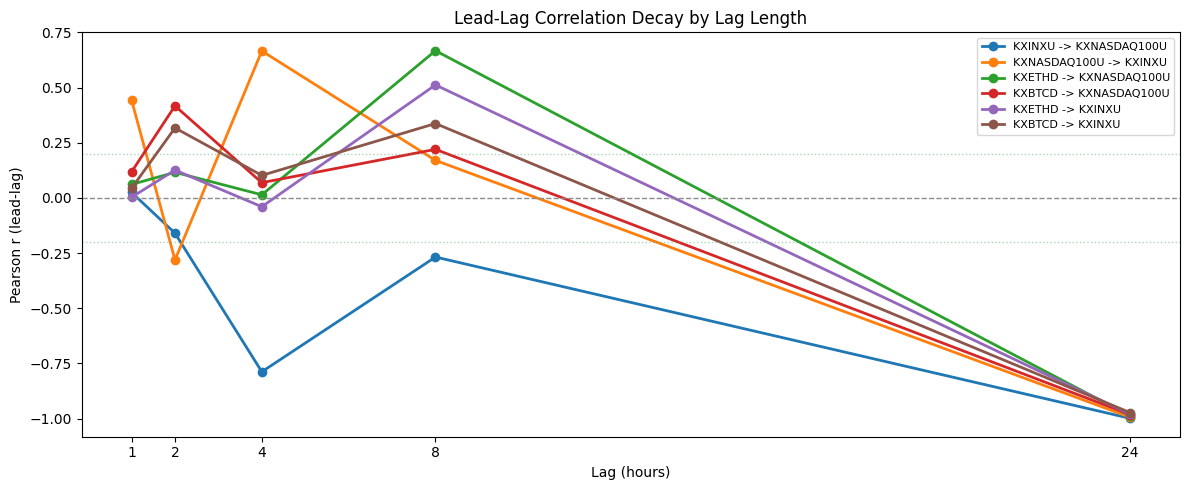

In [8]:
# Multi-lag lead-lag analysis: test t+1h, t+2h, t+4h, t+8h, t+24h
# Pivot is already reindexed to a complete hourly grid from above.

LAGS_TO_TEST = [1, 2, 4, 8, 24]  # hours

if "pivot" in dir() and not pivot.empty and len(target_cols) >= 2:
    # Compute lead-lag for each lag, for all target-target pairs
    multi_lag_results = {}  # {(col_a, col_b, lag): r}

    for lag in LAGS_TO_TEST:
        for col_a in target_cols:
            for col_b in target_cols:
                if col_a >= col_b:
                    continue
                # A at t predicts B at t+lag
                b_future = pivot[col_b].shift(-lag)
                valid = pivot[col_a].notna() & b_future.notna()
                if valid.sum() >= 10:
                    r = pivot[col_a][valid].corr(b_future[valid])
                    multi_lag_results[(col_a, col_b, lag)] = round(r, 3)

                # B at t predicts A at t+lag
                a_future = pivot[col_a].shift(-lag)
                valid = pivot[col_b].notna() & a_future.notna()
                if valid.sum() >= 10:
                    r = pivot[col_b][valid].corr(a_future[valid])
                    multi_lag_results[(col_b, col_a, lag)] = round(r, 3)

    # Build a DataFrame for display: rows = directed pairs, columns = lags
    pairs_seen = set()
    for (a, b, lag) in multi_lag_results:
        pairs_seen.add((a, b))

    lag_table = []
    for (a, b) in sorted(pairs_seen):
        row = {"pair": f"{a} -> {b}"}
        for lag in LAGS_TO_TEST:
            row[f"t+{lag}h"] = multi_lag_results.get((a, b, lag), np.nan)
        lag_table.append(row)

    df_lags = pd.DataFrame(lag_table).set_index("pair")

    # Filter to pairs where any lag has |r| > 0.15 (worth examining)
    interesting = df_lags[df_lags.abs().max(axis=1) > 0.15]

    print(f"Multi-lag lead-lag correlations — {len(interesting)} pairs with max |r| > 0.15:")
    print("(signal should decay with lag if real — stronger at t+24h than t+1h is suspicious)\n")
    display(interesting.round(3))

    # Plot decay curves for top pairs
    if not interesting.empty:
        top_pairs = interesting.abs().max(axis=1).nlargest(6).index
        fig, ax = plt.subplots(figsize=(12, 5))
        for pair in top_pairs:
            vals = [interesting.loc[pair, f"t+{lag}h"] for lag in LAGS_TO_TEST]
            ax.plot(LAGS_TO_TEST, vals, marker="o", label=pair, linewidth=2)
        ax.axhline(y=0, color=COLORS["muted"], linestyle="--", linewidth=1)
        ax.axhline(y=0.2, color=COLORS["profit"], linestyle=":", linewidth=1, alpha=0.5)
        ax.axhline(y=-0.2, color=COLORS["profit"], linestyle=":", linewidth=1, alpha=0.5)
        ax.set_xlabel("Lag (hours)")
        ax.set_ylabel("Pearson r (lead-lag)")
        ax.set_title("Lead-Lag Correlation Decay by Lag Length")
        ax.set_xticks(LAGS_TO_TEST)
        ax.legend(fontsize=8, loc="best")
        plt.tight_layout()
        plt.show()
else:
    print("No pivot data available — run Step 5 first")

---
## Step 6 — Informed Limit-Order P&L Simulation

**Purpose:** Simulate the informed limit-order strategy (Approach A from deep research)
to estimate P&L under idealized conditions.

**Strategy logic:**
1. Model estimates fair value `p_model` for each contract
2. If `p_model > market_ask + maker_fee`: post a BUY limit at `market_ask` (maker)
3. If `p_model < market_bid - maker_fee`: post a SELL limit at `market_bid` (maker)
4. **NaiveFillModel**: assume fill when market price touches the limit
5. Kelly-size positions (fractional Kelly for risk management)

**Important caveats:**
- This is a **conservative upper bound** — real fills have adverse selection
  (you get filled because someone with better information is trading against you)
- NaiveFillModel assumes no queue priority, no partial fills, no slippage
- Adverse selection modeling is deferred to Phase 2 (`AdverseSelectionFillModel`)

**Requires:** Model probabilities attached to snapshots (e.g., from `AnchorStrategy`)

In [9]:
# Informed limit-order P&L simulation using NaiveFillModel.
# simulate_maker_pnl() walks through snapshots and simulates maker trades
# with maker fees (not taker) and Kelly-optimal position sizing.
#
# NOTE: This reimplements EV + Kelly logic inline rather than reusing compute_ev()
# from ev.py, because the maker fee path and NaiveFillModel fill assumptions differ
# from the taker-oriented production pipeline. This is a documented deviation —
# if ev.py gains maker support, this should be refactored to call it.


def simulate_maker_pnl(
    snapshots: pd.DataFrame,
    model_prob_col: str = "anchor_prob",
    ev_threshold: float = 0.02,
    kelly_fraction: float = 0.25,
    initial_bankroll: float = 10_000.0,
) -> dict:
    """Simulate informed limit-order strategy with maker fees.

    For each contract snapshot:
    - Compute maker EV using model probability vs market price
    - If EV > threshold, 'post' a limit order at current bid/ask
    - Assume NaiveFillModel: fill if outcome matches direction
    - Kelly-size the position (fractional Kelly for safety)

    Returns dict with trade count, win rate, total P&L, and trade-level details.
    """
    bankroll = initial_bankroll
    trades = []

    for _, row in snapshots.iterrows():
        if model_prob_col not in row or pd.isna(row[model_prob_col]):
            continue

        p_model = row[model_prob_col]
        yes_price = row.get("yes_price") or row.get("entry_price")
        if yes_price is None or pd.isna(yes_price):
            continue

        # Compute maker fee at this price level
        fee = kalshi_fee(yes_price, is_taker=False)

        # EV for each side: model_prob - entry_price - fee
        ev_yes = p_model - yes_price - fee
        ev_no = (1 - p_model) - (1 - yes_price) - fee

        # Pick the better side, require minimum EV threshold
        if ev_yes > ev_no and ev_yes > ev_threshold:
            direction = "yes"
            ev = ev_yes
            entry = yes_price
        elif ev_no > ev_threshold:
            direction = "no"
            ev = ev_no
            entry = 1 - yes_price
        else:
            continue

        # Kelly sizing: optimal bet fraction given edge and payout
        # total_cost = entry + fee (what you risk per contract)
        # net_profit_if_win = 1 - fee - entry (payout minus cost)
        # payout_ratio = net_profit / total_cost (for Kelly b parameter)
        prob = p_model if direction == "yes" else (1 - p_model)
        total_cost = entry + fee
        payout_ratio = (1 - fee - entry) / total_cost
        if payout_ratio <= 0:
            continue
        kelly = kelly_criterion(prob, payout_ratio)
        bet = min(bankroll * kelly * kelly_fraction, bankroll * 0.10)  # cap at 10%
        if bet < 1.0:  # minimum $1 bet
            continue

        # Resolve: did this contract settle in our favor?
        outcome = row.get("outcome")
        if outcome is None or pd.isna(outcome):
            continue

        won = (direction == "yes" and outcome == 1.0) or (
            direction == "no" and outcome == 0.0
        )
        pnl = bet * payout_ratio if won else -bet
        bankroll += pnl

        trades.append({
            "contract_id": row.get("contract_id") or row.get("ticker", ""),
            "direction": direction,
            "entry": entry,
            "fee": fee,
            "ev": ev,
            "p_model": prob,
            "bet": bet,
            "pnl": pnl,
            "bankroll": bankroll,
            "won": won,
        })

    total_pnl = bankroll - initial_bankroll
    wins = sum(1 for t in trades if t["won"])
    return {
        "trades": len(trades),
        "wins": wins,
        "win_rate": wins / len(trades) if trades else 0,
        "total_pnl": total_pnl,
        "total_return": total_pnl / initial_bankroll,
        "final_bankroll": bankroll,
        "trade_list": trades,
    }


# Usage: once data collection is running and model probabilities are available:
#   result = simulate_maker_pnl(df, model_prob_col='calibrated_prob')
#   trades_df = pd.DataFrame(result['trade_list'])
#   trades_df['bankroll'].plot(title='Equity Curve')
print("Maker P&L simulation ready.")
print("Once data collection is running, load snapshots with model probabilities and call:")
print("  result = simulate_maker_pnl(df, model_prob_col='calibrated_prob')")
print("  pd.DataFrame(result['trade_list'])")

Maker P&L simulation ready.
Once data collection is running, load snapshots with model probabilities and call:
  result = simulate_maker_pnl(df, model_prob_col='calibrated_prob')
  pd.DataFrame(result['trade_list'])


---
## Step 7 — Summary & Decision Gate

**Purpose:** Aggregate all findings from Steps 1-6 to make an explicit go/no-go
decision on Phase 2 (strategy infrastructure).

**Green-light criteria (all must pass to proceed):**
- C1: Theoretical maker edge > 1% in at least 2 target series
- C2: Lead-lag correlation `|r| > 0.2` for at least 1 target pair (t → t+1, not contemporaneous)
- C3: Sufficient volume (> 50 contracts/day) in at least 2 target series

**Red flags (any one = stop and reconsider):**
- Edge < maker fee across all categories (no opportunity exists)
- All lead-lag correlations < 0.1 (cross-category updating won't work)
- Order books consistently empty (< 2 levels) in target markets

**Decision outcome:**
- **GO**: Proceed to Phase 2 — build MakerStrategy with maker fees + conservative fill assumption
- **NO-GO**: Pivot to different strategy or different platform
- **CONDITIONAL**: Need more data — extend collection period and re-run

**Important caveats (from deep-review):**
1. C1 edge is pre-adverse-selection (dominant maker cost not modeled)
2. NaiveFillModel in Step 6 assumes fills only when you win (inverted adverse selection)
3. Real edge will be lower — Phase 2C will build AdverseFillModel from empirical data

In [10]:
# Decision gate: programmatic GO / NO-GO / CONDITIONAL evaluation
# based on criteria from Steps 1-6.

print("=" * 60)
print("MAKER STRATEGY DATA ANALYSIS — DECISION GATE")
print("=" * 60)

# --- Data prerequisites ---
checks = {
    "Snapshot data loaded": not df.empty,
    "Order book data collected": len(ob_data) > 0,
    "Candlestick data collected": len(candle_data) > 0,
}

print("\nData prerequisites:")
for check, passed in checks.items():
    status = "PASS" if passed else "PENDING"
    icon = "+" if passed else "-"
    print(f"  [{icon}] {check}: {status}")

if not all(checks.values()):
    remaining = [k for k, v in checks.items() if not v]
    print(f"\n{len(remaining)} prerequisite(s) pending — cannot evaluate decision gate.")
    print("Run: make maker-data")
else:
    reasons = []

    # --- Criterion 1: avg_maker_edge > 0.01 in >= 2 series ---
    print("\n" + "-" * 60)
    print("CRITERION 1: avg_maker_edge > 0.01 in >= 2 target series")
    print("  (NOTE: edge is pre-adverse-selection — real edge will be lower)")
    c1_pass = False
    if "edge_summary" in dir() and not edge_summary.empty:
        target_edge_c1 = edge_summary.loc[
            edge_summary.index.isin(TARGET_SERIES) & (edge_summary["avg_maker_edge"] > 0.01)
        ]
        all_passing_c1 = edge_summary[edge_summary["avg_maker_edge"] > 0.01]
        print(f"  Target series passing: {len(target_edge_c1)} — {list(target_edge_c1.index)}")
        print(f"  All series passing:    {len(all_passing_c1)}")
        if len(target_edge_c1) >= 2:
            c1_pass = True
            reasons.append(f"C1 PASS: {len(target_edge_c1)} target series have edge > 0.01")
        elif len(all_passing_c1) >= 2:
            c1_pass = True
            reasons.append(
                f"C1 PASS (non-target): {len(all_passing_c1)} total series have edge > 0.01 "
                f"(but only {len(target_edge_c1)} are targets)"
            )
        else:
            reasons.append(f"C1 FAIL: only {len(all_passing_c1)} series have edge > 0.01")
    else:
        reasons.append("C1 FAIL: edge_summary not computed (run Step 4)")
    print(f"  -> {'PASS' if c1_pass else 'FAIL'}")

    # --- Criterion 2: lead-lag |r| > 0.2 between target pairs with sufficient sample size ---
    print("\n" + "-" * 60)
    print("CRITERION 2: any lead-lag |r| > 0.2 between target pairs (t -> t+1)")
    print(f"  (requires n >= {MIN_PAIRS_RELIABLE} overlapping hours for reliability)")
    c2_pass = False
    if "lead_lag_target" in dir() and lead_lag_target:
        # Only count pairs that are BOTH strong AND have sufficient sample size
        credible_strong = [
            (pair, r) for pair, r in lead_lag_target.items()
            if abs(r) > 0.2 and lead_lag_target_n.get(pair, 0) >= MIN_PAIRS_RELIABLE
        ]
        all_strong = [
            (pair, r) for pair, r in lead_lag_target.items() if abs(r) > 0.2
        ]
        if credible_strong:
            c2_pass = True
            for pair, r in sorted(credible_strong, key=lambda x: abs(x[1]), reverse=True):
                n = lead_lag_target_n[pair]
                print(f"  {pair}: r={r:+.3f}  n={n}")
            reasons.append(
                f"C2 PASS: {len(credible_strong)} target pair(s) with lead-lag |r| > 0.2 "
                f"and n >= {MIN_PAIRS_RELIABLE}"
            )
        else:
            max_r = max(abs(r) for r in lead_lag_target.values()) if lead_lag_target else 0
            if all_strong:
                low_n = [lead_lag_target_n.get(p, 0) for p, _ in all_strong]
                reasons.append(
                    f"C2 FAIL: {len(all_strong)} pair(s) have |r| > 0.2 but ALL have "
                    f"n < {MIN_PAIRS_RELIABLE} (max n={max(low_n)}) — insufficient data"
                )
            else:
                reasons.append(
                    f"C2 FAIL: no target pairs with lead-lag |r| > 0.2 (max |r|={max_r:.3f})"
                )
    elif "lead_lag_results" in dir() and lead_lag_results:
        any_strong = [(p, r) for p, r in lead_lag_results.items() if abs(r) > 0.2]
        reasons.append(
            f"C2 FAIL: no target-target lead-lag data "
            f"({len(any_strong)} non-target pairs have |r| > 0.2)"
        )
    else:
        reasons.append("C2 FAIL: lead-lag analysis not computed (run Step 5)")
    print(f"  -> {'PASS' if c2_pass else 'FAIL'}")

    # --- Criterion 3: volume sufficiency in target series ---
    print("\n" + "-" * 60)
    print("CRITERION 3: avg_volume > 50 contracts/day in >= 2 target series")
    c3_pass = False
    if "summary" in dir() and not summary.empty:
        target_vol_c3 = summary.loc[
            summary.index.isin(TARGET_SERIES) & (summary["avg_volume"] > 50)
        ]
        print(f"  Target series with avg_volume > 50: {len(target_vol_c3)} — {list(target_vol_c3.index)}")
        if len(target_vol_c3) >= 2:
            c3_pass = True
            reasons.append(f"C3 PASS: {len(target_vol_c3)} target series have volume > 50")
        else:
            reasons.append(f"C3 FAIL: only {len(target_vol_c3)} target series have volume > 50")
    else:
        reasons.append("C3 FAIL: summary not computed (run Step 1)")
    print(f"  -> {'PASS' if c3_pass else 'FAIL'}")

    # --- Final verdict ---
    print("\n" + "=" * 60)
    all_pass = c1_pass and c2_pass and c3_pass
    any_pass = c1_pass or c2_pass or c3_pass

    if all_pass:
        verdict = "GO"
        verdict_msg = (
            "All criteria met. Proceed to Phase 2 (MakerStrategy + conservative fill assumption).\n"
            "  CAVEAT: C1 edge is pre-adverse-selection. Phase 2C must validate with empirical fill data."
        )
    elif any_pass:
        verdict = "CONDITIONAL"
        verdict_msg = "Some criteria met. Extend data collection and re-evaluate."
    else:
        verdict = "NO-GO"
        verdict_msg = "No criteria met. Pivot to different strategy or platform."

    print(f"VERDICT: {verdict}")
    print(f"  {verdict_msg}")
    print()
    for r in reasons:
        print(f"  {r}")
    print("=" * 60)

MAKER STRATEGY DATA ANALYSIS — DECISION GATE

Data prerequisites:
  [+] Snapshot data loaded: PASS
  [+] Order book data collected: PASS
  [+] Candlestick data collected: PASS

------------------------------------------------------------
CRITERION 1: avg_maker_edge > 0.01 in >= 2 target series
  (NOTE: edge is pre-adverse-selection — real edge will be lower)
  Target series passing: 8 — ['KXNASDAQ100U', 'KXINXU', 'KXCPI', 'KXETHD', 'KXJOBLESSCLAIMS', 'KXCPIYOY', 'KXCPICOREYOY', 'KXPAYROLLS']
  All series passing:    407
  -> PASS

------------------------------------------------------------
CRITERION 2: any lead-lag |r| > 0.2 between target pairs (t -> t+1)
  (requires n >= 30 overlapping hours for reliability)
  KXNASDAQ100U -> KXINXU: r=+0.443  n=35
  -> PASS

------------------------------------------------------------
CRITERION 3: avg_volume > 50 contracts/day in >= 2 target series
  Target series with avg_volume > 50: 9 — ['KXNASDAQ100U', 'KXINXU', 'KXCPI', 'KXETHD', 'KXJOBLESSCLA